In [1]:
#Total mensual de viajeros internacionales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential, save_model, load_model
from keras.layers import Dense, LSTM, Dropout
from keras.callbacks import EarlyStopping
from keras.metrics import MeanSquaredError, RootMeanSquaredError
from keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
import keras

In [3]:
df = pd.read_csv("./df/Base_Migracion_2009-2026jun.csv")

df['Viajero'] = pd.to_numeric(df['Viajero'], errors='coerce')

# Subconjunto consistente para todo el período 2009-2026
# entre 2022-2023 la categoría 'Viajero' excluyó viajeros no turísticos de alta frecuencia
# (comercio fronterizo, tránsito), por lo que solo Turista + Excursionista son comparables
df_te = df[df['Tipo de Viajero'].isin(['Turista', 'Excursionista'])].copy()

print(f"Total filas: {len(df)}, Turista+Excursionista: {len(df_te)}")
df.head(3)

df_te = df[df['Tipo de Viajero'].isin(['Turista', 'Excursionista'])].copy()
df_te['Fecha'] = pd.to_datetime(df_te['Año'].astype(str) + '-' + df_te['Mes cod'].astype(str) + '-01')


Total filas: 161036, Turista+Excursionista: 137642


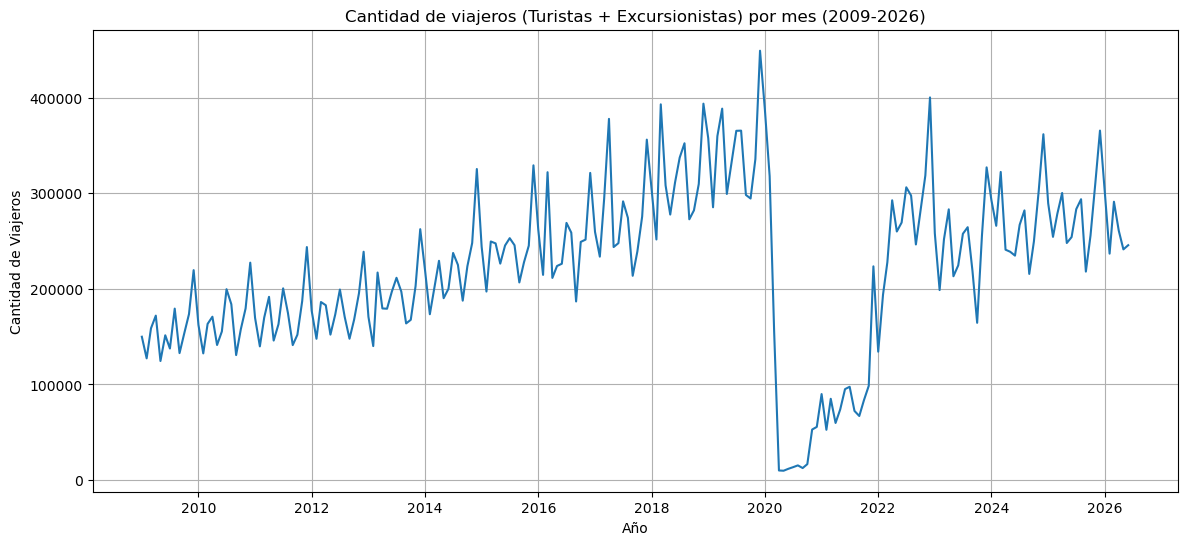

In [4]:
#VIAJEROS MENSUALES
viajeros_mensuales = df_te.groupby('Fecha')['Viajero'].sum().reset_index()
viajeros_mensuales.set_index('Fecha', inplace=True)

plt.figure(figsize=(14, 6))
plt.plot(viajeros_mensuales)
plt.gca().set(title="Cantidad de viajeros (Turistas + Excursionistas) por mes (2009-2026)", xlabel="Año", ylabel="Cantidad de Viajeros")
plt.grid(True)
plt.show()

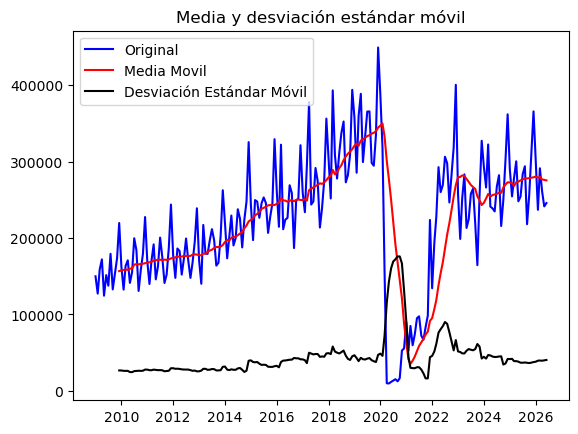

In [5]:
#media y desviacion estandar
mediaMovil = viajeros_mensuales.rolling(window=12).mean()
deMovil = viajeros_mensuales.rolling(window=12).std()

original = plt.plot(viajeros_mensuales, color="blue", label="Original")
media = plt.plot(mediaMovil, color='red', label = 'Media Movil')
ds = plt.plot(deMovil,color='black', label = 'Desviación Estándar Móvil')
plt.legend(loc = 'best')
plt.title('Media y desviación estándar móvil')
plt.show(block=False)

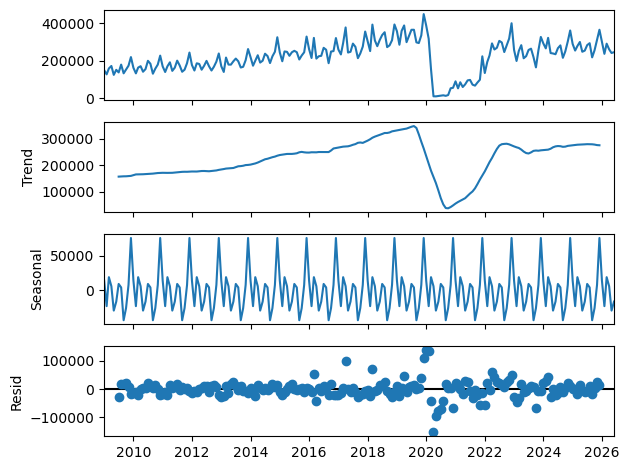

In [6]:
descomposicion = seasonal_decompose(viajeros_mensuales)
descomposicion.plot();

In [7]:
print("Test Dickey Fuller")
testDf = adfuller(viajeros_mensuales, autolag='AIC')
salidaDf = pd.Series(testDf[0:4], index=['Estadístico de prueba','p-value','No. retardos usados','No. observaciones usadas'])
for key, value in testDf[4].items():
    salidaDf['Critical Value (%s)' %key] = value
print(salidaDf)

Test Dickey Fuller
Estadístico de prueba        -2.886311
p-value                       0.046963
No. retardos usados          14.000000
No. observaciones usadas    195.000000
Critical Value (1%)          -3.464337
Critical Value (5%)          -2.876479
Critical Value (10%)         -2.574733
dtype: float64


p-value = 0.046963, menor a 0.05, es estacionaria por lo que no hay necesidad de diferenciar la serie.

In [8]:
#normalizar serie
scaler = StandardScaler()
serie_scaled = scaler.fit_transform(viajeros_mensuales.values.reshape(-1,1))
print("Datos normalizados: ")
print(serie_scaled[0:7].flatten())

Datos normalizados: 
[-0.85767986 -1.12554003 -0.75295514 -0.59657406 -1.15800656 -0.83994771
 -1.00352279]


In [9]:
#Division de datos para train y test
total_len = len(serie_scaled)
train_size = int(0.6 * total_len)
val_size = int(0.2 * total_len)
test_size = total_len - train_size - val_size

train = serie_scaled[0:train_size]
validation = serie_scaled[train_size:train_size+val_size]
test = serie_scaled[train_size+val_size:]

print(f"Entrenamiento: {len(train)}")
print(f"Validación: {len(validation)}")
print(f"Prueba: {len(test)}")

Entrenamiento: 126
Validación: 42
Prueba: 42


In [10]:
def make_secuencias(serie, retrasos=1):
    X, y = [], []
    for i in range(len(serie)-retrasos):
        X.append(serie[i:(i+retrasos), 0])
        y.append(serie[i+retrasos, 0])
    return np.array(X), np.array(y)
#seuencuas
n_pasos = 12 #meses
X_train, y_train = make_secuencias(train, n_pasos)
X_val, y_val = make_secuencias(validation, n_pasos)
X_test, y_test = make_secuencias(test, n_pasos)
print("=== Secuencias ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

#redimension LTSM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1)) #[muestras, pasos_tiempo, carac.]
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print("=== Redimension ===")
print(f"X_train reshaped: {X_train.shape}")
print(f"X_val reshaped: {X_val.shape}")
print(f"X_test reshaped: {X_test.shape}")

=== Secuencias ===
X_train shape: (114, 12)
X_val shape: (30, 12)
X_test shape: (30, 12)
=== Redimension ===
X_train reshaped: (114, 12, 1)
X_val reshaped: (30, 12, 1)
X_test reshaped: (30, 12, 1)


### Modelo 1: LSTM Básico (TensorFlow/Keras)

c:\Users\abbyd\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Modelo 1 - Resumen:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 587ms/step - loss: 0.6417 - root_mean_squared_error: 0.8011 - val_loss: 2.6429 - val_root_mean_squared_error: 1.6257
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.5837 - root_mean_squared_error: 0.7640 - val_loss: 2.4326 - val_root_mean_squared_error: 1.5597
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.5286 - root_mean_squared_error: 0.7270 - val_loss: 2.2316 - val_root_mean_squared_error: 1.4939
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.4797 - root_mean_squared_error: 0.6926 - val_loss: 2.0263 - val_root_mean_squared_error: 1.4235
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.4241 - root_mean_squared_error: 0.6513 - val_loss: 1.8138 - val_root_mean_squared_error: 1.3468
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.3683 - root_mean_squared_error: 0.6069 - val_loss: 1.5973 - val_root_mean_squared_error: 1.2639
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.31

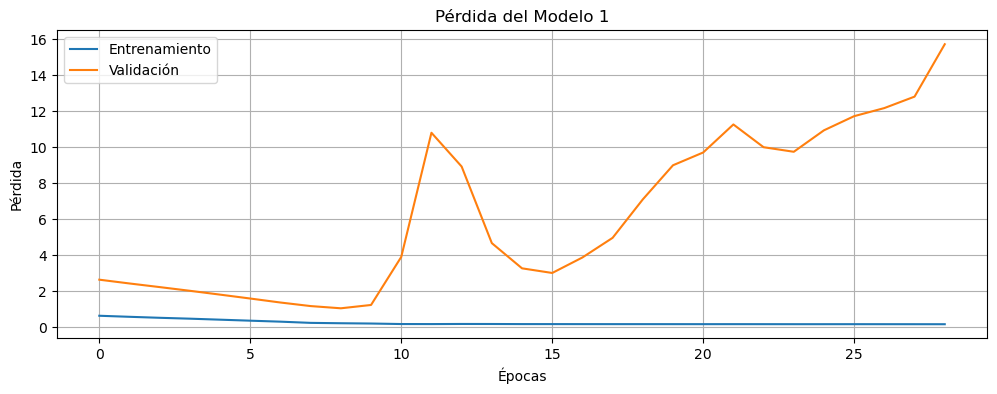

Evaluación del Modelo 1:
Entrenamiento:
Validación:
Prueba:


[0.23206350207328796, 0.4817296862602234]

In [11]:
modelo1 = Sequential([
    LSTM(50, activation='relu', input_shape=(n_pasos, 1)),
    Dense(1)
])

modelo1.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='mse',
    metrics=[RootMeanSquaredError()]
)
print("Modelo 1 - Resumen:")
modelo1.summary()

#Early stopping
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True
)

#train
history1 = modelo1.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

#graficas
plt.figure(figsize=(12, 4))
plt.plot(history1.history['loss'], label='Entrenamiento')
plt.plot(history1.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo 1')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

#eval
print("Evaluación del Modelo 1:")
print("Entrenamiento:")
modelo1.evaluate(X_train, y_train, verbose=0)
print("Validación:")
modelo1.evaluate(X_val, y_val, verbose=0)
print("Prueba:")
modelo1.evaluate(X_test, y_test, verbose=0)

### Modelo 2: Mas complejidad

Modelo 2 - Resumen:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 12, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,626 (307.13 KB)

 Trainable params: 78,626 (307.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 521ms/step - loss: 0.5496 - root_mean_squared_error: 0.7414 - val_loss: 2.4060 - val_root_mean_squared_error: 1.5511
Epoch 2/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.4977 - root_mean_squared_error: 0.7055 - val_loss: 2.3546 - val_root_mean_squared_error: 1.5345
Epoch 3/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.4164 - root_mean_squared_error: 0.6453 - val_loss: 2.2795 - val_root_mean_squared_error: 1.5098
Epoch 4/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2978 - root_mean_squared_error: 0.5457 - val_loss: 2.4120 - val_root_mean_squared_error: 1.5531
Epoch 5/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.2201 - root_mean_squared_error: 0.4692 - val_loss: 19.1969 - val_root_mean_squared_error: 4.3814
Epoch 6/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.1779 - root_mean_squared_error: 0.4218 - val_loss: 11.1463 - val_root_mean_squared_error: 3.3386
Epoch 7/150
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.

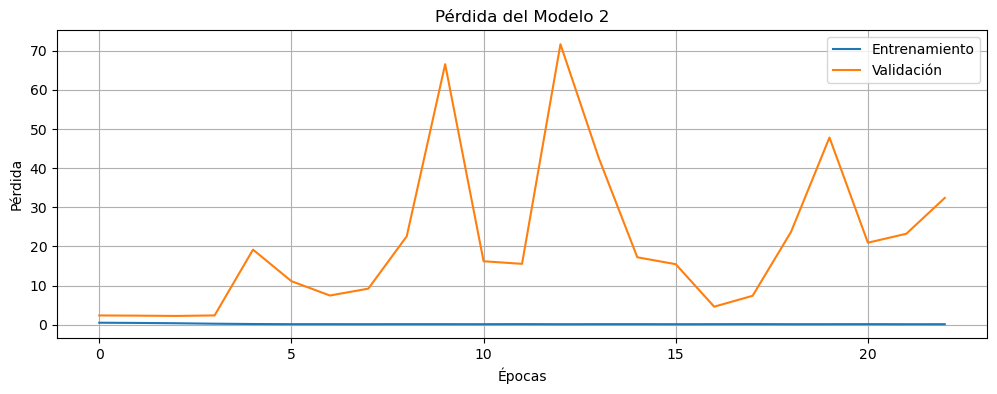

In [12]:
modelo2 = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(n_pasos, 1)),
    Dropout(0.2),
    LSTM(50, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(25, activation='relu'),
    Dropout(0.1),
    Dense(1)
])

modelo2.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss='mse',
    metrics=[RootMeanSquaredError()]
)
print("Modelo 2 - Resumen:")
modelo2.summary()

#train 2
history2 = modelo2.fit(
    X_train, y_train,
    epochs=150,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

#graficas 2
plt.figure(figsize=(12, 4))
plt.plot(history2.history['loss'], label='Entrenamiento')
plt.plot(history2.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo 2')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
#inversion transformacion y prediccion

def prediccion_desnormalizacion(modelo, X_data, scaler, serie_original, start_idx, n_pasos=1):
    #Predice y desnormaliza los datos para obtener valores en la escala original
    predicciones = []
    for X in X_data:
        X_reshaped = X.reshape((1, n_pasos, 1))
        y_pred_scaled = modelo.predict(X_reshaped, verbose=0)
        predicciones.append(y_pred_scaled[0, 0])
    
    predicciones = np.array(predicciones).reshape(-1, 1)
    predicciones_diff = scaler.inverse_transform(predicciones)
    
    #inversa diferenciacion
    predicciones_original = []
    for i, pred in enumerate(predicciones_diff):
        if i == 0:
            #1era prediccion, suma a valor anteririr en original
            idx = start_idx + n_pasos + i
            valor_anterior = serie_original.iloc[idx - 1]
        else:
            #sig, suma diferencia acumulada
            valor_anterior = predicciones_original[-1]
        predicciones_original.append(valor_anterior + pred[0])
    
    return np.array(predicciones_original)

### Predicciones

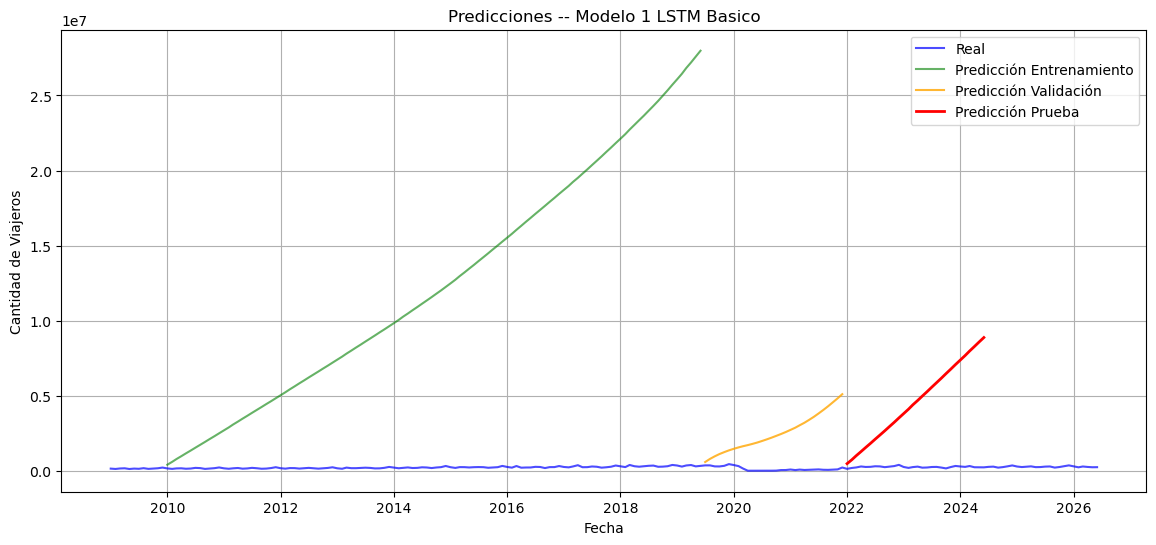

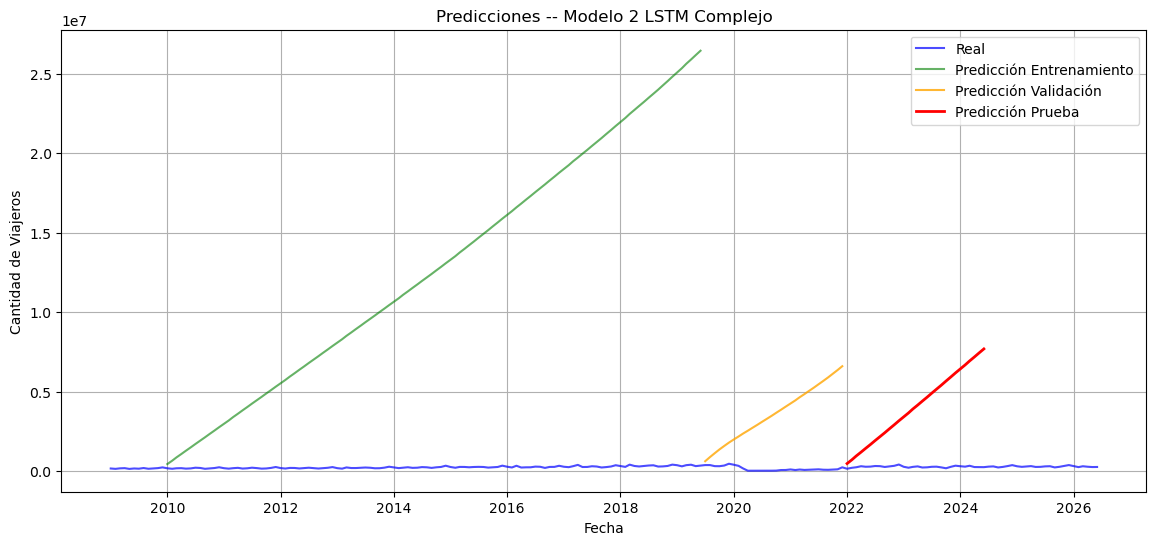

In [14]:
start_train = len(train) - n_pasos
start_val = start_train + len(validation) - n_pasos
start_test = start_val + len(test) - n_pasos

#predicciones modelo 1
pred_train1 = prediccion_desnormalizacion(modelo1, X_train, scaler, viajeros_mensuales, 0, n_pasos)
pred_val1 = prediccion_desnormalizacion(modelo1, X_val, scaler, viajeros_mensuales, start_train, n_pasos)
pred_test1 = prediccion_desnormalizacion(modelo1, X_test, scaler, viajeros_mensuales, start_val, n_pasos)

#predicciones modelo 2
pred_train2 = prediccion_desnormalizacion(modelo2, X_train, scaler, viajeros_mensuales, 0, n_pasos)
pred_val2 = prediccion_desnormalizacion(modelo2, X_val, scaler, viajeros_mensuales, start_train, n_pasos)
pred_test2 = prediccion_desnormalizacion(modelo2, X_test, scaler, viajeros_mensuales, start_val, n_pasos)


#graficas predicciones
def graficas(serie_original, pred_train, pred_val, pred_test, titulo):
    plt.figure(figsize=(14, 6))
    
    #Original
    plt.plot(serie_original.index, serie_original.values, label='Real', color='blue', alpha=0.7)
    #predicciones orignal
    train_idx = serie_original.index[n_pasos:n_pasos+len(pred_train)]
    val_idx = serie_original.index[start_train+n_pasos:start_train+n_pasos+len(pred_val)]
    test_idx = serie_original.index[start_val+n_pasos:start_val+n_pasos+len(pred_test)]
    
    plt.plot(train_idx, pred_train, label='Predicción Entrenamiento', color='green', alpha=0.6)
    plt.plot(val_idx, pred_val, label='Predicción Validación', color='orange', alpha=0.8)
    plt.plot(test_idx, pred_test, label='Predicción Prueba', color='red', linewidth=2)
    
    plt.title(titulo)
    plt.xlabel('Fecha')
    plt.ylabel('Cantidad de Viajeros')
    plt.legend()
    plt.grid(True)
    plt.show()

#graficas preudcciones modelo 1
graficas(
    viajeros_mensuales, 
    pred_train1, pred_val1, pred_test1,
    'Predicciones -- Modelo 1 LSTM Basico'
)

#grafiacs predicciones modelo 2
graficas(
    viajeros_mensuales, 
    pred_train2, pred_val2, pred_test2,
    'Predicciones -- Modelo 2 LSTM Complejo'
)

### Comparacion de modelos

In [15]:
def metricas(y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae = mean_absolute_error(y_real, y_pred)
    return rmse, mae

# Modelo 1 - Test
y_test_real = viajeros_mensuales.values[start_val+n_pasos:start_val+n_pasos+len(pred_test1)]
rmse1, mae1 = metricas(y_test_real, pred_test1)

# Modelo 2 - Test
y_test_real2 = viajeros_mensuales.values[start_val+n_pasos:start_val+n_pasos+len(pred_test2)]
rmse2, mae2 = metricas(y_test_real2, pred_test2)

print("="*60)
print("COMPARACION MODELOS")
print("="*60)
print(f"\nModelo 1 (LSTM Basico):")
print(f"  RMSE: {rmse1:.2f}")
print(f"  MAE: {mae1:.2f}")
print(f"\nModelo 2 (LSTM Complejo):")
print(f"  RMSE: {rmse2:.2f}")
print(f"  MAE: {mae2:.2f}")

print("\nEl mejor modelo es: ")

if rmse1 < rmse2:
    print(f"\tModelo 1 (RMSE: {rmse1:.2f})")
else:
    print(f"\tModelo 2 (RMSE: {rmse2:.2f})")

COMPARACION MODELOS

Modelo 1 (LSTM Basico):
  RMSE: 5012083.35
  MAE: 4334282.40

Modelo 2 (LSTM Complejo):
  RMSE: 4353201.60
  MAE: 3780694.17

El mejor modelo es: 
	Modelo 2 (RMSE: 4353201.60)


### Predicciones a futuro

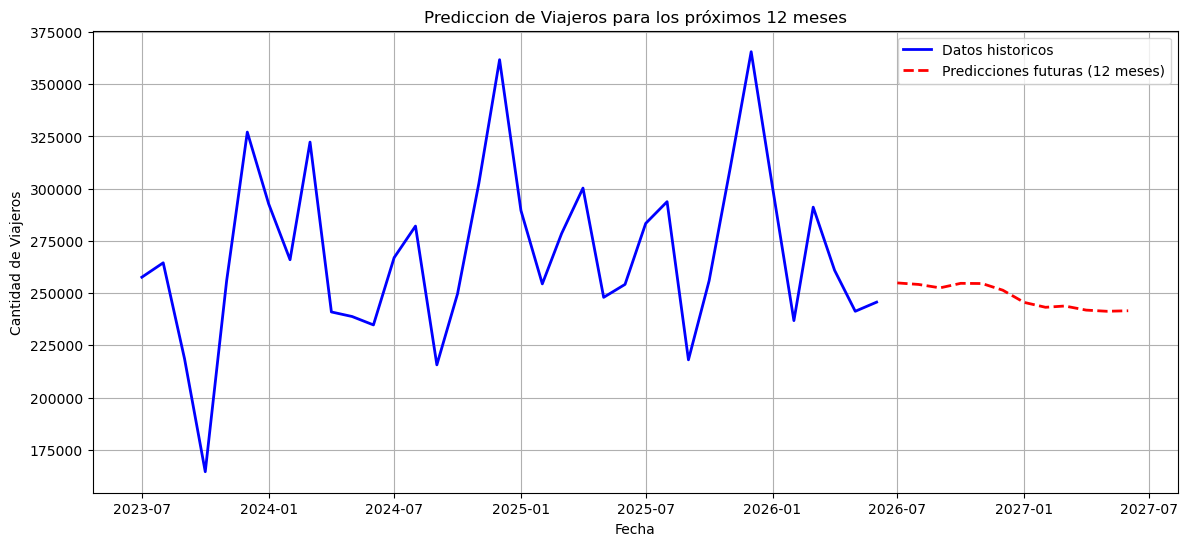

Predicciones para los próximos 12 meses:
     Fecha    Prediccion
2026-07-01 254888.906250
2026-08-01 254156.140625
2026-09-01 252522.875000
2026-10-01 254689.531250
2026-11-01 254592.671875
2026-12-01 251407.953125
2027-01-01 245570.906250
2027-02-01 243219.968750
2027-03-01 243831.750000
2027-04-01 241873.765625
2027-05-01 241313.140625
2027-06-01 241559.781250


In [ ]:
def predicciones_futuro(modelo, datos_scaled, scaler, n_pasos, n_predicciones):
    ultima_secuencia = datos_scaled[-n_pasos:].reshape(1, n_pasos, 1)
    predicciones = []
    
    for _ in range(n_predicciones):
        #prediuccion sigueinte
        pred_scaled = modelo.predict(ultima_secuencia, verbose=0)
        predicciones.append(pred_scaled[0, 0])
        
        ultima_secuencia = np.append(
            ultima_secuencia[:, 1:, :], 
            pred_scaled.reshape(1, 1, 1), 
            axis=1
        )
    
    #desnormalizar
    predicciones = np.array(predicciones).reshape(-1, 1)
    predicciones_original = scaler.inverse_transform(predicciones)
    
    return predicciones_original.flatten()

#mejor modelo para hacer preducciones
mejor_modelo = modelo1 if rmse1 < rmse2 else modelo2

future_pred = predicciones_futuro(
    mejor_modelo, 
    serie_scaled, 
    scaler,
    n_pasos, 
    12
)

#crear futuras fechas
last_date = viajeros_mensuales.index[-1]
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1), 
    periods=12, 
    freq='MS'
)

#graficas
plt.figure(figsize=(14, 6))
plt.plot(viajeros_mensuales.index[-36:], viajeros_mensuales.values[-36:], 
         label='Datos historicos', linewidth=2, color='blue')
plt.plot(future_dates, future_pred, 
         label='Predicciones futuras (12 meses)', linewidth=2, 
         linestyle='--', color='red')
plt.title('Prediccion de Viajeros para los próximos 12 meses')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Viajeros')
plt.legend()
plt.grid(True)
plt.show()

print("Predicciones para los próximos 12 meses:")
pred_df = pd.DataFrame({
    'Fecha': future_dates,
    'Prediccion': future_pred
})
print(pred_df.to_string(index=False))

### RESUMEN

In [22]:
print("=== RESUMEN FINAL SERIE LSTM ===")
print(f"- Periodo: {viajeros_mensuales.index.min()} - {viajeros_mensuales.index.max()}")
print(f"   + Meses totales: {len(viajeros_mensuales)}")
print("- Serie estacionaria: 0.046963")
print("- Modelos entrenados:")
print(f"   + Modelo 1: LSTM basico (1 capa)\n\t Rendimiento:\n\t¬ RMSE:{rmse1:.2f}\n\t¬ MAE:{mae1:.2f}")
print(f"   + Modelo 2: LSTM avanzado (3 capas)\n\t Rendimiento:\n\t¬ RMSE:{rmse2:.2f}\n\t¬ MAE:{mae2:.2f}")
print(f"\nMejor modelo: {'Modelo 1' if rmse1 < rmse2 else 'Modelo 2'}")
print("Predicciones para proximos 12 meses:")
print(f"  Rango: {future_dates[0].strftime('%Y-%m')} a {future_dates[-1].strftime('%Y-%m')}")
print(f"  Total estimado: {future_pred.sum():.0f} viajeros")

=== RESUMEN FINAL SERIE LSTM ===
- Periodo: 2009-01-01 00:00:00 - 2026-06-01 00:00:00
   + Meses totales: 210
- Serie estacionaria: 0.046963
- Modelos entrenados:
   + Modelo 1: LSTM basico (1 capa)
	 Rendimiento:
	¬ RMSE:5012083.35
	¬ MAE:4334282.40
   + Modelo 2: LSTM avanzado (3 capas)
	 Rendimiento:
	¬ RMSE:4353201.60
	¬ MAE:3780694.17

Mejor modelo: Modelo 2
Predicciones para proximos 12 meses:
  Rango: 2026-07 a 2027-06
  Total estimado: 2979628 viajeros


## CATCH22

In [39]:
from scipy import stats, signal
from statsmodels.tsa.stattools import acf, pacf
from scipy.fft import fft, fftfreq
from scipy.stats import entropy
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from matplotlib.colors import LinearSegmentedColormap

In [32]:
class Catch22:
    def __init__(self, series):
        self.series = np.array(series).flatten()
        self.n = len(self.series)

    def extract(self):
        features_catch = {}

        #estadisticas basicas
        features_catch['mean'] = np.mean(self.series)
        features_catch['std'] = np.std(self.series, ddof=1)
        features_catch['skewness'] = stats.skew(self.series)
        features_catch['kurtosis'] = stats.kurtosis(self.series)
        features_catch['mean_abs_dev'] = np.mean(np.abs(self.series - np.mean(self.series)))
        features_catch['median_abs_dev'] = np.median(np.abs(self.series - np.median(self.series)))
        features_catch['iqr'] = np.percentile(self.series, 75) - np.percentile(self.series, 25)
        features_catch['cv'] = np.std(self.series, ddof=1) / (np.abs(np.mean(self.series)) + 1e-10)

        #auto correalcion
        if self.n > 2:
            acf_values = acf(self.series, nlags=2, fft=False)
            features_catch['autocorrelation_lag1'] = acf_values[1] if len(acf_values)>1 else np.nan
            features_catch['autocorrelation_lag2'] = acf_values[2] if len(acf_values) > 2 else np.nan
        else:
            features_catch['autocorrelation_lag1'] = np.nan
            features_catch['autocorrelation_lag2'] = np.nan

        #peak
        peak = signal.find_peaks(self.series)[0]
        features_catch['num_peaks'] = len(peak)
        features_catch['mean_peaks'] = np.mean(self.series[peak]) if len(peak) >0 else np.nan
        features_catch['std_peaks'] = np.std(self.series[peak], ddof=1) if len(peak)>1 else np.nan

        #cruce 0
        zero_crossing = np.where(np.diff(np.sign(self.series)))[0]
        features_catch['first_zero_crossing'] = zero_crossing[0] if len(zero_crossing) > 0 else self.n

        #espctraels
        fft_values = np.fft.fft(self.series)
        power = np.abs(fft_values)**2
        features_catch['max_power_spectrum'] = np.max(power[1:]) if len(power) > 1 else np.nan
        freqs = np.fft.fftfreq(self.n)
        idx_max = np.argmax(power[1:]) + 1 if len(power) > 1 else 0
        features_catch['dominant_frequency'] = freqs[idx_max] if idx_max > 0 else np.nan
        power_norm = power / (np.sum(power) + 1e-10)
        features_catch['spectral_entropy'] = entropy(power_norm + 1e-10)

        #entropaia
        features_catch['approximate_entropy'] = self.entropia_aprox()
        features_catch['sample_entropy'] = self.entropia_muestra()



        #grafica histo
        histo, _ = np.histogram(self.series, bins=10)
        histo = histo / (np.sum(histo) + 1e-10)
        features_catch['histogram_entropy'] = entropy(histo[histo > 0] + 1e-10)
        
        #fractal
        features_catch['dfa_alpha'] = self.expo_dfa_alpha()
        features_catch['hurst_exponent'] = self.expo_hust()
        
        return features_catch

    def entropia_aprox(self, m=2, r=0.2):
        if self.n < m + 1:
            return np.nan
        r = r * np.std(self.series)
        if r == 0:
            return 0
        def _phi(m):
            N = self.n - m + 1
            X = np.array([self.series[i:i+m] for i in range(N)])
            C = np.zeros(N)
            for i in range(N):
                C[i] = np.sum(np.max(np.abs(X[i] - X), axis=1) <= r) / N
            return np.sum(np.log(C + 1e-10)) / N
        phi_m = _phi(m)
        phi_m1 = _phi(m+1)
        return phi_m - phi_m1

    def entropia_muestra(self, m=2, r=0.2):
        if self.n < m + 1:
            return np.nan
        r = r * np.std(self.series)
        if r == 0:
            return 0
        def _phi(m):
            N = self.n - m + 1
            X = np.array([self.series[i:i+m] for i in range(N)])
            count = 0
            for i in range(N-1):
                for j in range(i+1, N):
                    if np.max(np.abs(X[i] - X[j])) <= r:
                        count += 1
            return count / (N * (N-1) / 2) if N > 1 else 0
        A = _phi(m+1)
        B = _phi(m)
        if B == 0:
            return np.nan
        return -np.log(A / (B + 1e-10))

    def expo_dfa_alpha(self):
        if self.n <10:
            return np.nan
        y = np.cumsum(self.series - np.mean(self.series))
        scales= np.unique(np.logspace(np.log10(4), np.log10(self.n//4), 10).astype(int))
        scales = scales[scales>=2]
        fluctuations = []
        for scale in scales:
            if scale < 2:
                continue
            n_segments = len(y)//scale
            if n_segments < 2:
                continue
            rms = []
            for i in range(n_segments):
                segment = y[i*scale:(i+1)*scale]
                x = np.arange(len(segment))
                coeffs = np.polyfit(x, segment, 1)
                trend = np.polyval(coeffs, x)
                rms.append(np.sqrt(np.mean((segment-trend)**2)))
            if rms:
                fluctuations.append(np.mean(rms))
        if len(fluctuations)< 2:
            return np.nan
        return np.polyfit(np.log(scales[:len(fluctuations)]), np.log(fluctuations), 1)[0]

    def expo_hust(self):
        if self.n < 10:
            return np.nan
        max_lag = self.n // 4
        lags = np.unique(np.logspace(0, np.log10(max_lag), 10).astype(int))
        lags = lags[lags >= 2]

        rs = []

        for lag in lags:
            n_segments = self.n//lag
            if n_segments < 2:
                continue
            rs_values = []
            for i in range(n_segments):
                segment = self.series[i*lag:(i+1)*lag]
                if len(segment) < 2:
                    continue
                mean = np.mean(segment)
                cumsum = np.cumsum(segment-mean)
                r = np.max(cumsum)-np.min(cumsum)
                s = np.std(segment, ddof=1)
                if s > 0:
                    rs_values.append(r/s)
            if rs_values:
                rs.append(np.mean(rs_values))
        if len(rs) < 2:
            return np.nan
        return np.polyfit(np.log(lags[:len(rs)]), np.log(rs), 1)[0]

def make_matriz_22(series_dict):
    #fila = serie, colum = caract 22
    matrix = []
    noms = []

    for nom, serie in series_dict.items():
        catch22 = Catch22(serie)
        features_catch = catch22.extract()
        matrix.append(features_catch)
        noms.append(nom)

    df_features22 = pd.DataFrame(matrix, index=noms)
    return df_features22

### aplicar a serie

In [33]:
#preparacion y hacer matriz
series_dict = {
    'Viajeros_Original': viajeros_mensuales.values.flatten(),
    'Viajeros_Log': np.log(viajeros_mensuales.values.flatten() + 1),  # Transformación log
    'Viajeros_Diferenciada': viajeros_mensuales.diff().fillna(0).values.flatten(),
    'Serie_Aleatoria': np.random.randn(len(viajeros_mensuales)),
    'Tendencia': np.linspace(0, 1, len(viajeros_mensuales)) + 0.3 * np.random.randn(len(viajeros_mensuales)),
    'Estacional_Pura': 10 * np.sin(2 * np.pi * np.arange(len(viajeros_mensuales)) / 12) + np.random.randn(len(viajeros_mensuales)) * 0.5
}

matriz_catch22 = make_matriz_22(series_dict)

print("=== Matriz ===")
print(f"Dimensiones: {matriz_catch22.shape} (filas: {len(matriz_catch22)}, columnas: {len(matriz_catch22.columns)})")
print(f"Fragmento:\n{matriz_catch22.head()}")

=== Matriz ===
Dimensiones: (6, 22) (filas: 6, columnas: 22)
Fragmento:
                                mean           std  skewness  kurtosis  \
Viajeros_Original      222437.680412  84724.938827 -0.282534  0.149131   
Viajeros_Log               12.182493      0.642528 -2.751185  9.038645   
Viajeros_Diferenciada     455.921674  50128.438646 -0.326727  0.393623   
Serie_Aleatoria             0.010011      0.943949 -0.076852  0.069295   
Tendencia                   0.511706      0.402673 -0.099751 -0.063429   

                       mean_abs_dev  median_abs_dev            iqr  \
Viajeros_Original      66356.681102    55070.071582  107626.732203   
Viajeros_Log               0.401755        0.246969       0.488852   
Viajeros_Diferenciada  39848.452059    32474.410244   67295.438351   
Serie_Aleatoria            0.740707        0.617503       1.187037   
Tendencia                  0.321550        0.279717       0.549905   

                               cv  autocorrelation_lag1  autoc

### Estandariacion y analisis

=== Matriz Estandarizada ===
Dimensiones: (6, 22)

Caracteristicas estandarizadas:
                           mean       std  skewness  kurtosis  mean_abs_dev  \
Viajeros_Original      2.236064  1.868390  0.323874 -0.345336      1.858788   
Viajeros_Log          -0.448197 -0.674638 -2.222714  2.202732     -0.676274   
Viajeros_Diferenciada -0.442842  0.829964  0.278286 -0.275255      0.846073   
Serie_Aleatoria       -0.448344 -0.674629  0.536049 -0.368220     -0.676261   
Tendencia             -0.448338 -0.674645  0.512427 -0.406264     -0.676277   
Estacional_Pura       -0.448342 -0.674442  0.572078 -0.807658     -0.676048   

                       median_abs_dev       iqr        cv  \
Viajeros_Original            1.870521  1.831705 -0.887385   
Viajeros_Log                -0.674301 -0.680574 -0.894564   
Viajeros_Diferenciada        0.826357  0.890267  1.509458   
Serie_Aleatoria             -0.674284 -0.680557  1.166969   
Tendencia                   -0.674299 -0.680572 -0.878503 

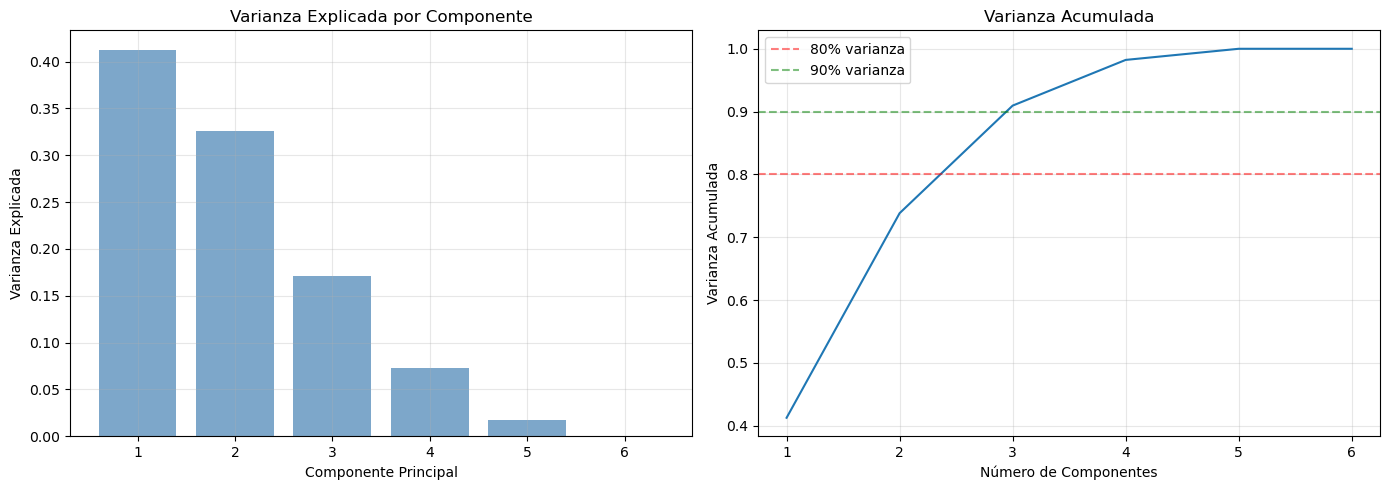


=== Clustering ===


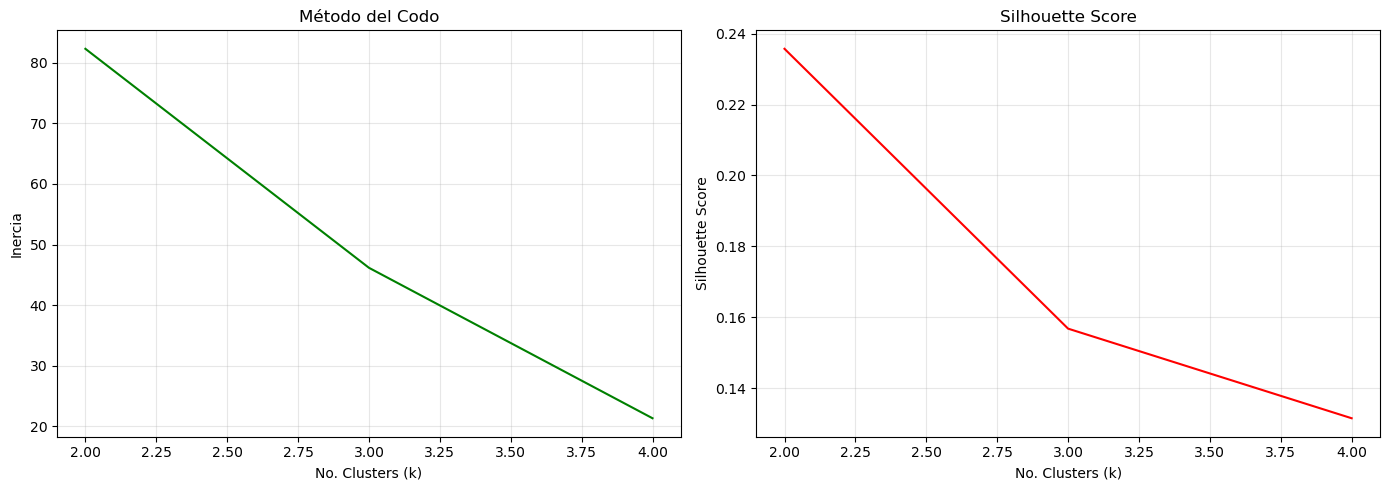


Mejor no. de clusters: 2
   - Silhouette Score: 0.236
Distribucion series por cluster:
  Cluster 0: ['Viajeros_Log', 'Viajeros_Diferenciada', 'Serie_Aleatoria', 'Tendencia', 'Estacional_Pura']
  Cluster 1: ['Viajeros_Original']

=== Heatmap ===


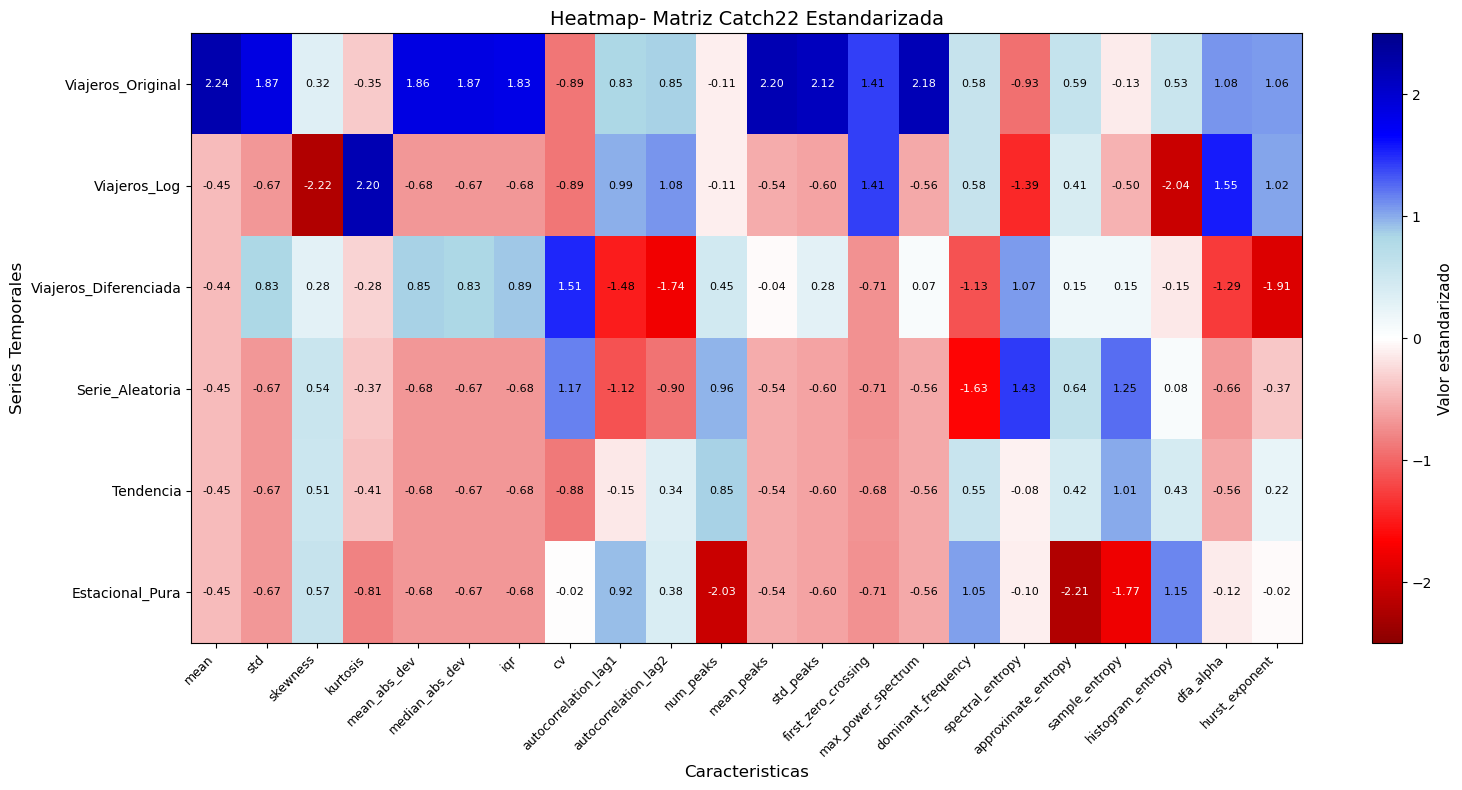

In [40]:
#estadnarizacion
def estandarizacion(df_features22):
    df_numeric = df_features22.select_dtypes(include=[np.number]) #numericas

    scaler = StandardScaler()
    df_scale = pd.DataFrame(
        scaler.fit_transform(df_numeric),
        index=df_numeric.index,
        columns=df_numeric.columns
    )
    df_scale.attrs['scaler'] = scaler

    return df_scale

matriz_catch22_estandar = estandarizacion(matriz_catch22)

print("=== Matriz Estandarizada ===")
print(f"Dimensiones: {matriz_catch22_estandar.shape}")
print("\nCaracteristicas estandarizadas:")
print(matriz_catch22_estandar)

print("=== Estadisticas ===")
print(f"Media por caracteristica: {matriz_catch22_estandar.mean().round(3)}")
print(f"Desviacion estandar por caracteristica: {matriz_catch22_estandar.std().round(3)}")
print(f"Rango por caracteristica: {(matriz_catch22_estandar.max() -matriz_catch22_estandar.min()).round(3)}")

#analisis

#PCA
pca = PCA()
pca_serie = pca.fit_transform(matriz_catch22_estandar)

df_pca = pd.DataFrame(pca_serie, index=matriz_catch22_estandar.index, columns=[f'PC{i+1}' for i in range(pca_serie.shape[1])])

#varianza (explanied variance)
exp_varianza = pca.explained_variance_ratio_
cumulative_varianza = np.cumsum(exp_varianza)

print("\n=== PCA ===")
print(f"Varianza explicada por componente:")
for i, (ev,cv) in enumerate(zip(exp_varianza, cumulative_varianza)):
    print(f"  -PC {i+1}: {ev:.2%} (acumulado: {cv:.2%})")
print(f"\nPrimeras 2 componentes explican: {cumulative_varianza[1]:.2%} de la varianza")
print(f"Primeras 3 componentes explican: {cumulative_varianza[2]:.2%} de la varianza")
#grafica
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#varianza explicada (individual)
ax1.bar(range(1, len(exp_varianza)+1), exp_varianza, alpha=0.7, color='steelblue')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza Explicada')
ax1.set_title('Varianza Explicada por Componente')
ax1.grid(True, alpha=0.3)

# Varianza acumulada
ax2.plot(range(1, len(cumulative_varianza)+1),cumulative_varianza)
ax2.axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='80% varianza')
ax2.axhline(y=0.9, color='g', linestyle='--', alpha=0.5, label='90% varianza')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Acumulada')
ax2.set_title('Varianza Acumulada')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()


print("\n=== Clustering ===")
if len(matriz_catch22_estandar) >= 4:
    max_k = min(4, len(matriz_catch22_estandar) - 1)
    K_range = range(2, max_k + 1)
    
    if len(K_range) > 0:
        inertias = []
        silhouette_scores = []
        
        for k in K_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(matriz_catch22_estandar)
            inertias.append(kmeans.inertia_)
            silhouette_scores.append(silhouette_score(matriz_catch22_estandar, kmeans.labels_))
        
        #grafica
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        ax1.plot(K_range, inertias, color='green')
        ax1.set_xlabel('No. Clusters (k)')
        ax1.set_ylabel('Inercia')
        ax1.set_title('Método del Codo')
        ax1.grid(True, alpha=0.3)
        
        ax2.plot(K_range, silhouette_scores, color='red')
        ax2.set_xlabel('No. Clusters (k)')
        ax2.set_ylabel('Silhouette Score')
        ax2.set_title('Silhouette Score')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        #mejor k
        best_k = K_range[np.argmax(silhouette_scores)]
        print(f"\nMejor no. de clusters: {best_k}")
        print(f"   - Silhouette Score: {max(silhouette_scores):.3f}")
        #kmeans
        kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(matriz_catch22_estandar)
        
        print("Distribucion series por cluster:")
        for cluster in range(best_k):
            series = matriz_catch22_estandar.index[clusters == cluster].tolist()
            print(f"  Cluster {cluster}: {series}")

    else:
        print("No se puede hacer clustering")
else:
    print("Se necesitan al menos 4 series para hacer clustering")

print("\n=== Heatmap ===")

#heatmap
colors = ['darkred', 'red', 'lightcoral', 'white', 'lightblue', 'blue', 'darkblue']
cmap_custom = LinearSegmentedColormap.from_list('custom_rdbu', colors, N=256)
fig, ax = plt.subplots(figsize=(16, 8))

im = ax.imshow(matriz_catch22_estandar.values, 
               cmap=cmap_custom, 
               aspect='auto', 
               vmin=-2.5, vmax=2.5,
               interpolation='nearest')

#ejes
ax.set_xticks(np.arange(len(matriz_catch22_estandar.columns)))
ax.set_yticks(np.arange(len(matriz_catch22_estandar.index)))
ax.set_xticklabels(matriz_catch22_estandar.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(matriz_catch22_estandar.index, fontsize=10)
#celdas valores
for i in range(len(matriz_catch22_estandar.index)):
    for j in range(len(matriz_catch22_estandar.columns)):
        valor = matriz_catch22_estandar.iloc[i, j]
        color_text = 'white' if abs(valor) > 1.5 else 'black'
        ax.text(j, i, f'{valor:.2f}',
                ha='center', va='center', 
                color=color_text, fontsize=8)

ax.set_title('Heatmap- Matriz Catch22 Estandarizada', fontsize=14)
ax.set_xlabel('Caracteristicas', fontsize=12)
ax.set_ylabel('Series Temporales', fontsize=12)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Valor estandarizado', fontsize=11)

plt.tight_layout()
plt.show()